In [6]:
# merge topic and sentiment dataset
import pandas as pd

sentiment_path = r"F:\ERP_data\final_corpusRCRS_sentiment.jsonl"
topic_path = r"F:\ERP_data\LDA_topic_assigned.csv"


df_sentiment = pd.read_json(
    sentiment_path,
    lines=True
)

df_topic = pd.read_csv(topic_path)

df_final = df_sentiment.merge(
    df_topic[['id','topic']],
    on='id',
    how='left'
)
  # save
output_path = r"F:\ERP_data\final_corpusRCRS_topic_sentiment.jsonl"


df_final.to_json(
    output_path,
    orient='records',
    lines=True,
    force_ascii=False
)

print("Saved:", output_path)

Saved: F:\ERP_data\final_corpusRCRS_topic_sentiment.jsonl


In [7]:
df_final['topic'].value_counts()

topic
2    1328
3     283
0     233
1     218
4     118
6     114
5     110
Name: count, dtype: int64

In [1]:
import pandas as pd

path = r"F:\ERP_data\final_corpusRCRS_topic_sentiment.jsonl"

df = pd.read_json(
    path,
    lines=True
)

df.shape

(2404, 99)

In [2]:
topic_counts = df['topic'].value_counts().sort_index()
topic_percentage = (
    topic_counts / len(df) * 100
).round(2)

topic_percentage

topic
0     9.69
1     9.07
2    55.24
3    11.77
4     4.91
5     4.58
6     4.74
Name: count, dtype: float64

In [3]:
topic_sentiment = pd.crosstab(
    df['topic'],
    df['sentiment_label'],
    normalize='index'
)

topic_sentiment_percent = (
    topic_sentiment * 100
).round(2)

topic_sentiment_percent

sentiment_label,negative,neutral,positive
topic,,,
0,23.18,19.31,57.51
1,36.24,16.97,46.79
2,32.61,6.70,60.69
3,22.26,10.95,66.78
4,6.78,45.76,47.46
5,30.00,18.18,51.82
6,42.11,15.79,42.11


In [4]:
topic_compound = (
    df.groupby('topic')['compound']
    .mean()
    .round(3)
)

topic_compound

topic
0    0.294
1    0.085
2    0.230
3    0.346
4    0.260
5    0.177
6    0.057
Name: compound, dtype: float64

In [13]:
topic_summary = topic_sentiment_percent.copy()

topic_summary['mean_compound'] = topic_compound

topic_summary['count'] = topic_counts

topic_summary

sentiment_label,negative,neutral,positive,mean_compound,count
topic,,,,,
0,23.18,19.31,57.51,0.294,233
1,36.24,16.97,46.79,0.085,218
2,32.61,6.70,60.69,0.230,1328
3,22.26,10.95,66.78,0.346,283
4,6.78,45.76,47.46,0.260,118
5,30.00,18.18,51.82,0.177,110
6,42.11,15.79,42.11,0.057,114


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# read topic + sentiment dataset
file_path = r"F:\ERP_data\final_corpusRCRS_topic_sentiment.jsonl"

df = pd.read_json(
    file_path,
    lines=True
)

print(df[['topic', 'sentiment_label']].head())

topic_sentiment_percent = (
    pd.crosstab(
        df['topic'],
        df['sentiment_label'],
        normalize='index'
    ) * 100
)

topic_sentiment_percent = topic_sentiment_percent[
    ['negative', 'neutral', 'positive']
]

print(topic_sentiment_percent.round(2))

   topic sentiment_label
0      2        positive
1      2        positive
2      3        positive
3      2        negative
4      2        positive
sentiment_label  negative  neutral  positive
topic                                       
0                   23.18    19.31     57.51
1                   36.24    16.97     46.79
2                   32.61     6.70     60.69
3                   22.26    10.95     66.78
4                    6.78    45.76     47.46
5                   30.00    18.18     51.82
6                   42.11    15.79     42.11


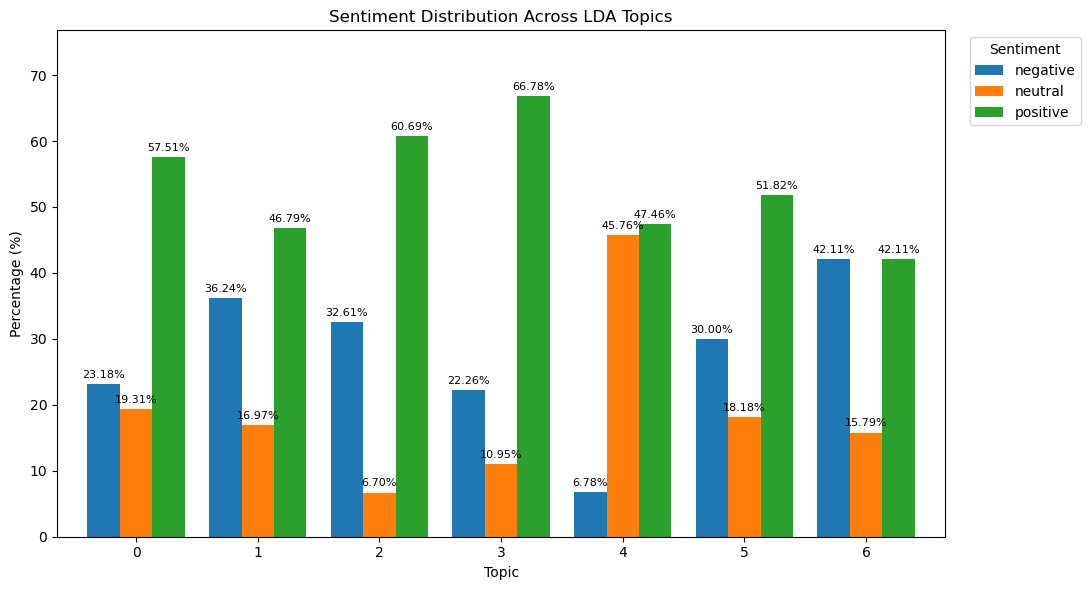

In [2]:
# visualise
ax = topic_sentiment_percent.plot(
    kind='bar',
    stacked=False,
    figsize=(11, 6),
    width=0.8
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=8
    )

plt.xlabel("Topic")
plt.ylabel("Percentage (%)")
plt.title("Sentiment Distribution Across LDA Topics")
plt.xticks(rotation=0)
plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.ylim(
    0,
    topic_sentiment_percent.max().max() + 10
)

plt.tight_layout()
plt.show()

In [5]:
# stat test
from scipy.stats import chi2_contingency
import pandas as pd

topic_sentiment_table = pd.crosstab(
    df['topic'],
    df['sentiment_label']
)

chi2, p, dof, expected = chi2_contingency(topic_sentiment_table)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)

Chi-square: 220.1768891577589
df: 12
p-value: 2.181310156750521e-40


In [6]:
import numpy as np

n = topic_sentiment_table.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 /
    (n * min(
        topic_sentiment_table.shape[0] - 1,
        topic_sentiment_table.shape[1] - 1
    ))
)

print("Cramer's V:", cramers_v)

Cramer's V: 0.21399500493618312
